# MLP (Multi-Layer Perceptron) — Baseline
Treino em 2020–2023, teste em 2024. Sem SMOTE — desbalanceamento tratado via `class_weight='balanced'`.
MLP requer dados sem NaN e features numéricas escaladas.
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [22]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR     = '../../data/features/baseline'
OUTPUT_MOD   = '../../output/modelos'
OUTPUT_MET   = '../../output/metricas'
ALGO         = 'mlp'
DATASET      = 'baseline'
RANDOM_STATE = 42
YEAR_COL     = 'year'

## 1. Carregamento dos dados

In [23]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

mask    = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

print(f'X_train: {X_train.shape} | Óbitos: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | Óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')

X_train: (137743, 52) | Óbitos: 2,640 (1.92%)
X_test:  (160534, 52)  | Óbitos: 5,295 (3.30%)


## 2. Pipeline
MLP exige dados completos (sem NaN) e features escaladas. O preprocessamento segue as mesmas
decisões da regressão logística: CS_RACA e CS_GESTANT com one-hot, CS_ESCOL_N ordinal.

In [24]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]
SYMP_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
]
SYMP_COLS = [c for c in SYMP_COLS if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        # Ausência informativa: NaN → 0
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        # Sintomas binários: NaN → moda
        ('sintomas',
         SimpleImputer(strategy='most_frequent'),
         SYMP_COLS),

        # Idade: mediana → escala
        ('age',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['age_years']),

        # epi_week: mediana → escala
        ('epi',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['epi_week']),

        # CS_SEXO: encode F→0/M→1 → moda
        ('sexo',
         Pipeline([
             ('enc', OrdinalEncoder(categories=[['F', 'M']],
                                    handle_unknown='use_encoded_value',
                                    unknown_value=np.nan)),
             ('imp', SimpleImputer(strategy='most_frequent')),
         ]),
         ['CS_SEXO']),

        # CS_ESCOL_N: ordinal com ordem natural → escala
        ('escol',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['CS_ESCOL_N']),

        # CS_RACA: categórica nominal → one-hot
        ('raca',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_RACA']),

        # CS_GESTANT: categórica com categorias especiais → one-hot
        ('gestant',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_GESTANT']),

        # SG_UF: encode ordinal → escala
        ('uf',
         Pipeline([
             ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
             ('scl', StandardScaler()),
         ]),
         ['SG_UF']),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )),
])

print('Pipeline definido.')

Pipeline definido.


## 3. Treinamento

In [25]:
def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_train_prep = prep_X(X_train)
X_test_prep  = prep_X(X_test)

# MLPClassifier não suporta class_weight — passa pesos por amostra no fit()
sample_weights = compute_sample_weight('balanced', y_train)

pipeline.fit(X_train_prep, y_train, clf__sample_weight=sample_weights)

clf = pipeline['clf']
print(f'Treinamento concluído — {clf.n_iter_} épocas | loss final: {clf.loss_:.4f}')

Treinamento concluído — 16 épocas | loss final: 0.1778


## 4. Curva de loss

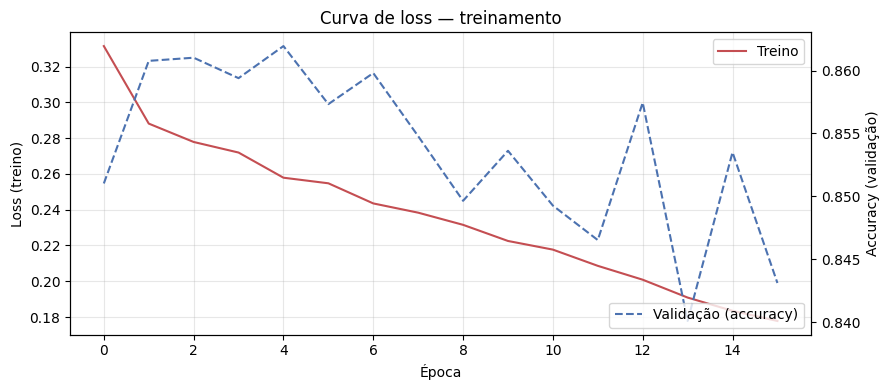

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(clf.loss_curve_, color='#C44E52', label='Treino')
if clf.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(clf.validation_scores_, color='#4C72B0', linestyle='--', label='Validação (accuracy)')
    ax2.set_ylabel('Accuracy (validação)')
    ax2.legend(loc='lower right')
ax.set_title('Curva de loss — treinamento')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (treino)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Avaliação

=== MLP — Baseline (2020–2023 → 2024) ===
  sensibilidade: 0.7843
  especificidade: 0.9081
  auprc: 0.6369
  roc_auc: 0.9217
  f1: 0.3503
  precisao: 0.2255
  threshold: 0.5
  n_train: 137743
  n_obito_train: 2640

              precision    recall  f1-score   support

        Cura       0.99      0.91      0.95    155239
       Óbito       0.23      0.78      0.35      5295

    accuracy                           0.90    160534
   macro avg       0.61      0.85      0.65    160534
weighted avg       0.97      0.90      0.93    160534



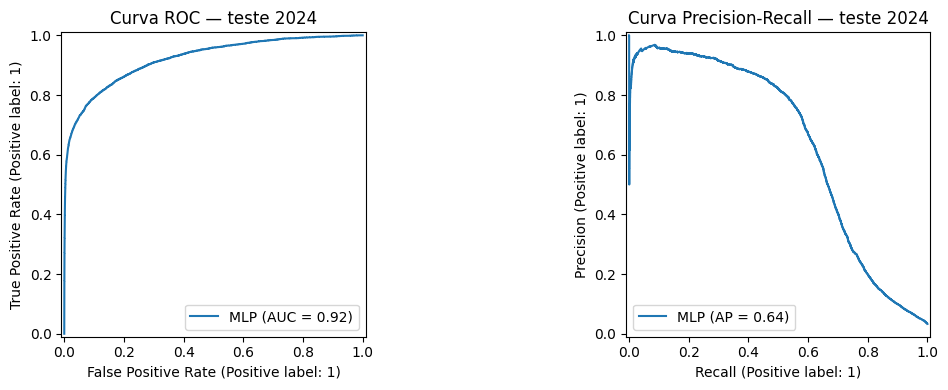

In [27]:
y_te  = y_test.dropna()
proba = pipeline.predict_proba(X_test_prep)[:, 1]
proba = proba[y_test.notna().values]

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        len(X_train_prep),
        'n_obito_train':  int(y_train.sum()),
    }

metricas = calcular_metricas(y_te, proba)
print('=== MLP — Baseline (2020–2023 → 2024) ===')
for k, v in metricas.items():
    print(f'  {k}: {v}')

print()
print(classification_report(y_te, (proba >= 0.5).astype(int), target_names=['Cura', 'Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[0], name='MLP')
axes[0].set_title('Curva ROC — teste 2024')
PrecisionRecallDisplay.from_predictions(y_te, proba, ax=axes[1], name='MLP')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

## 6. Matriz de Confusão (threshold = 0.5)

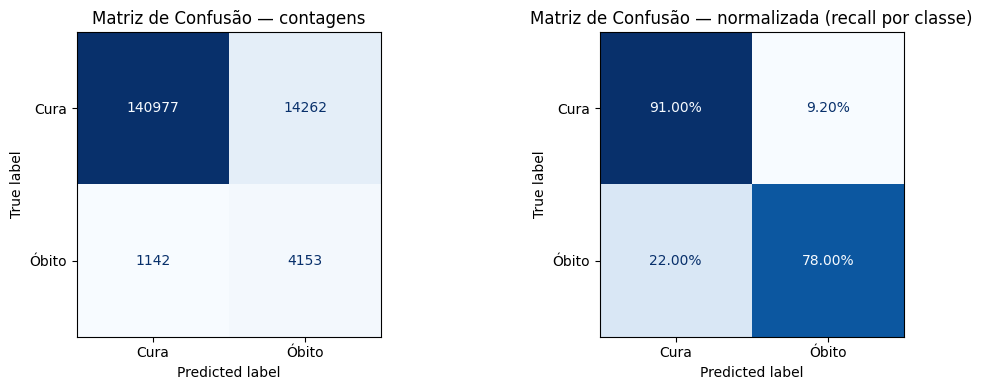

VP (óbitos detectados):   4,153
FN (óbitos perdidos):     1,142
FP (falsos alarmes):      14,262
VN (curas classificadas): 140,977


In [28]:
y_pred_05      = (proba >= 0.5).astype(int)
cm             = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 7. Análise de threshold

Threshold padrão  (0.50): sens=0.7843 | esp=0.9081
Threshold Youden  (0.50): sens=0.7843 | esp=0.9081
Threshold sens≥90% (0.15): sens=0.9201 | esp=0.6615


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9715,0.4028,0.0526,0.0997,5144,92710,151,62529
1,0.10,0.9460,0.5692,0.0697,0.1298,5009,66877,286,88362
2,0.15,0.9201,0.6615,0.0849,0.1554,4872,52545,423,102694
3,0.20,0.8988,0.7239,0.0999,0.1798,4759,42869,536,112370
4,0.25,0.8767,0.7725,0.1162,0.2052,4642,35315,653,119924
5,0.30,0.8567,0.8095,0.1330,0.2302,4536,29573,759,125666
6,0.35,0.8361,0.8405,0.1517,0.2568,4427,24760,868,130479
7,0.40,0.8179,0.8666,0.1729,0.2855,4331,20715,964,134524
8,0.45,0.8009,0.8890,0.1975,0.3168,4241,17235,1054,138004
9,0.50,0.7843,0.9081,0.2255,0.3503,4153,14262,1142,140977


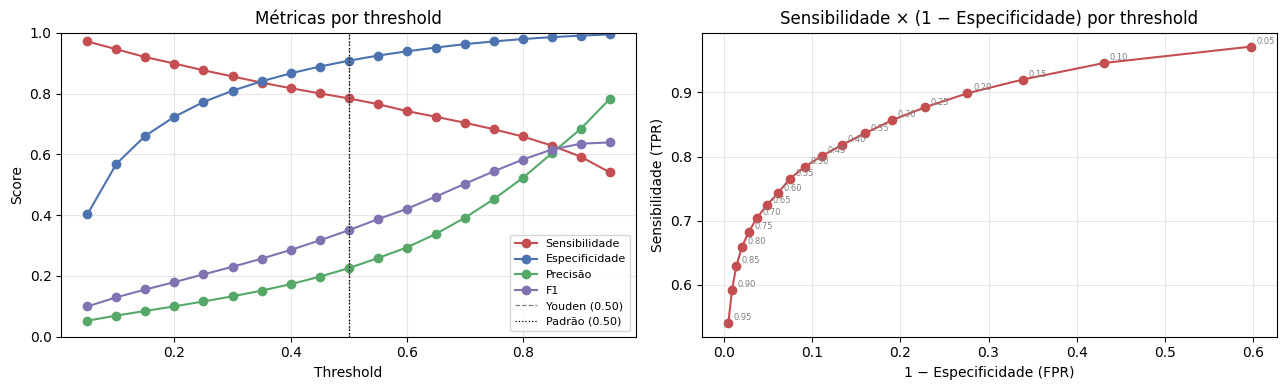

In [29]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90    = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sens={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} "
      f"| esp={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): "
      f"sens={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): "
          f"sens={df_thresh.loc[idx_90,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--',
                linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 − Especificidade) por threshold')
axes[1].set_xlabel('1 − Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Salvamento

In [30]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline, model_path)
print(f'Modelo salvo: {model_path}')

df_met = pd.DataFrame([metricas])
df_met['label']   = f'{ALGO}_{DATASET}'
df_met['dataset'] = DATASET
met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_met.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/mlp_baseline.joblib
Métricas salvas: ../../output/metricas/mlp_baseline.parquet
Predições salvas: ../../output/metricas/mlp_baseline_predicoes.parquet


## 9. Otimização de Hiperparâmetros (GridSearchCV)
`MLPClassifier` não aceita `class_weight` — o wrapper `BalancedMLP` computa `sample_weight` por fold
automaticamente dentro do `fit()`, garantindo balanceamento correto em cada divisão do CV.

Grid: `hidden_layer_sizes` × `alpha` × `learning_rate_init` = 3 × 3 × 2 = **18 combinações × 5 folds = 90 fits**.

In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

class BalancedMLP(MLPClassifier):
    """MLPClassifier com compute_sample_weight('balanced') aplicado por fold no CV."""
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight('balanced', y)
        return super().fit(X, y, sample_weight=sample_weight)

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', BalancedMLP(
            activation='relu',
            solver='adam',
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        )),
    ])

param_grid = {
    'clf__hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'clf__alpha':              [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.0001],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=build_pipeline(),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_prep, y_train)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUPRC (CV):   {grid_search.best_score_:.4f}')

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv = df_cv[['param_clf__hidden_layer_sizes', 'param_clf__alpha', 'param_clf__learning_rate_init',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
df_cv = df_cv.sort_values('rank_test_score')
display(df_cv)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Melhores parâmetros: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.001}
Melhor AUPRC (CV):   0.6466


,param_clf__hidden_layer_sizes,param_clf__alpha,param_clf__learning_rate_init,mean_test_score,std_test_score,rank_test_score
6,"(64, 32)",0.0010,0.0010,0.646641,0.021978,1
10,"(256, 128)",0.0010,0.0010,0.645075,0.019493,2
4,"(256, 128)",0.0001,0.0010,0.644456,0.023807,3
16,"(256, 128)",0.0100,0.0010,0.643580,0.021689,4
8,"(128, 64)",0.0010,0.0010,0.641638,0.024173,5
0,"(64, 32)",0.0001,0.0010,0.639576,0.028760,6
12,"(64, 32)",0.0100,0.0010,0.638551,0.029444,7
17,"(256, 128)",0.0100,0.0001,0.638482,0.023551,8
3,"(128, 64)",0.0001,0.0001,0.638066,0.021633,9
15,"(128, 64)",0.0100,0.0001,0.637961,0.021918,10


## 10. Avaliação — Modelo Tunado

=== Comparação: Baseline vs Tunado ===
Métrica              Baseline     Tunado
----------------------------------------
sensibilidade          0.7843     0.7664  (-0.0179)
especificidade         0.9081     0.9065  (-0.0016)
auprc                  0.6369     0.6272  (-0.0097)
roc_auc                0.9217     0.9157  (-0.0060)
f1                     0.3503     0.3400  (-0.0103)


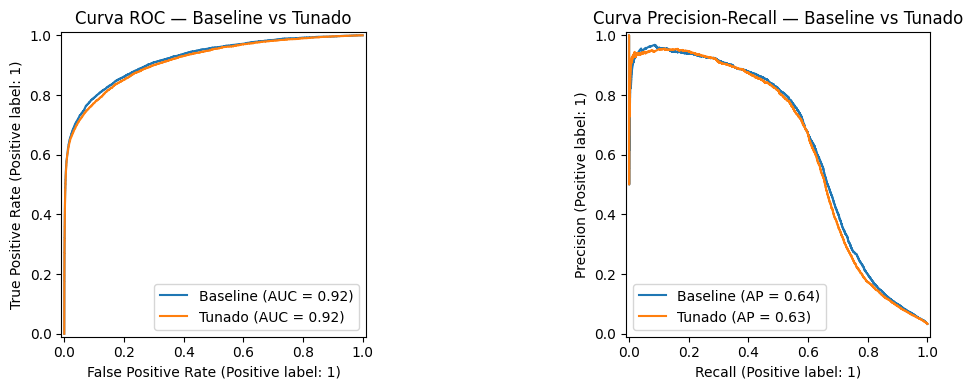

In [32]:
pipeline_tuned = grid_search.best_estimator_

proba_tuned = pipeline_tuned.predict_proba(X_test_prep)[:, 1]
proba_tuned = proba_tuned[y_test.notna().values]

metricas_tuned = calcular_metricas(y_te, proba_tuned)

print('=== Comparação: Baseline vs Tunado ===')
print(f"{'Métrica':<18} {'Baseline':>10} {'Tunado':>10}")
print('-' * 40)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_base  = metricas[k]
    v_tuned = metricas_tuned[k]
    diff    = v_tuned - v_base
    sinal   = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_base:>10.4f} {v_tuned:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba,       ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_te, proba_tuned, ax=axes[0], name='Tunado')
axes[0].set_title('Curva ROC — Baseline vs Tunado')

PrecisionRecallDisplay.from_predictions(y_te, proba,       ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_te, proba_tuned, ax=axes[1], name='Tunado')
axes[1].set_title('Curva Precision-Recall — Baseline vs Tunado')
plt.tight_layout()
plt.show()

## 11. Salvamento — Modelo Tunado

In [33]:
DATASET_TUNED = f'{DATASET}_tuned'

model_path_tuned = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET_TUNED}.joblib')
joblib.dump(pipeline_tuned, model_path_tuned)
print(f'Modelo salvo: {model_path_tuned}')

df_met_tuned = pd.DataFrame([metricas_tuned])
df_met_tuned['label']       = f'{ALGO}_{DATASET_TUNED}'
df_met_tuned['dataset']     = DATASET_TUNED
df_met_tuned['best_params'] = str(grid_search.best_params_)
met_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}.parquet')
df_met_tuned.to_parquet(met_path_tuned, index=False)
print(f'Métricas salvas: {met_path_tuned}')

df_pred_tuned = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_tuned})
pred_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}_predicoes.parquet')
df_pred_tuned.to_parquet(pred_path_tuned, index=False)
print(f'Predições salvas: {pred_path_tuned}')

Modelo salvo: ../../output/modelos/mlp_baseline_tuned.joblib
Métricas salvas: ../../output/metricas/mlp_baseline_tuned.parquet
Predições salvas: ../../output/metricas/mlp_baseline_tuned_predicoes.parquet


## 12. Conclusão

O MLP é o modelo mais competitivo após a regressão logística, com a **melhor AUPRC entre todos os modelos testados**.

| Modelo               | Sensibilidade  | Especificidade | AUPRC          | ROC-AUC        |
|----------------------|---------------|----------------|----------------|----------------|
| Logística (baseline) | **0.8004**    | 0.8853         | 0.6250         | **0.9242**     |
| MLP (baseline)       | 0.7843        | 0.9081         | **0.6369**     | 0.9217         |
| XGBoost (baseline)   | 0.7490        | 0.9098         | 0.6112         | 0.9098         |
| LightGBM (baseline)  | 0.6820        | 0.9520         | 0.6098         | 0.9024         |
| Random Forest        | 0.6240        | **0.9831**     | 0.6276         | 0.9209         |

**Observações:**
- AUPRC de 0.6369 é a mais alta entre todos os modelos — o MLP tem a melhor capacidade de rankear óbitos no topo da fila de prioridade.
- Sensibilidade de 0.7843 é apenas 1.6 pontos abaixo da logística, com especificidade superior (0.9081 vs 0.8853).
- A regressão logística ainda lidera na métrica prioritária #1 (sensibilidade). O MLP supera em AUPRC (prioridade #2).

**Modelo selecionado até o momento:** `logistic_regression_baseline` (sensibilidade) | `mlp_baseline` (AUPRC).